# Stage 2 Continued: Fine-Tuning Teeth Detection on DISEASE WITH HEALTHY Data

This notebook continues training the teeth enumeration model on the DISEASE_ONLY dataset prepared in the data preparation notebook. We start from stage 2's last checkpoint, fine-tune it on this narrower dataset, compare checkpoints, then sanity-check predictions the same way as before.

`smart_predict` and `compare_best_vs_last` come from `src/model_utils.py`.

Training here runs live, it's not commented out like in the earlier notebooks. The `on_fit_epoch_end` callback prompts for the current stage number when it's called, worth keeping in mind if this runs somewhere without a console attached, like Kaggle.

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')
# add the project root to the path so the src package can be imported
sys.path.append(os.path.abspath('..'))

import yaml
from ultralytics import YOLO
from src.model_utils import smart_predict,compare_best_vs_last

%matplotlib inline

## Load configs

We'll load the continued stage 2 config, stage 3 config, the data yaml, and the trained models config, then print each one out for a quick look.

In [2]:
with open('../configs/stage2_continued.yaml','r') as f:

    stage2_cont_config = yaml.safe_load(f)


with open('../configs/stage3.yaml','r') as f:

    stage3_config = yaml.safe_load(f)


# comes from stage2_cont_config, so that has to load first
with open(stage2_cont_config['model_args']['data'],'r') as f:

    enum_cont_data_yaml = yaml.safe_load(f)


with open('../configs/trained_models.yaml','r') as f:

    trained_models_config = yaml.safe_load(f)

In [3]:
stage2_cont_config

{'paths': {'original_images_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant-enumeration-disease/xrays',
  'original_json_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json',
  's2_cont_main_path': '../Data/Processed/Stage 2 Continued (Healthy & Disease Enumeration Detection)',
  'runs_s2_cont_output': '../Runs/Stage 2 Continued',
  'DISEASE_ONLY': {'s2_cont_main_path': '../Data/Processed/Stage 2 Continued (Healthy & Disease Enumeration Detection)/Disease Only'}},
 'model_args': {'data': '../Data/Processed/Stage 2 Continued (Healthy & Disease Enumeration Detection)/data.yaml',
  'model': '../Runs/Stage 2 Continued/weights/best.pt',
  'epochs': 50,
  'save': True,
  'imgsz': 1280,
  'batch': 8,
  'patience': 20,
  'optimizer': 'AdamW',
  'lr0': 0.0001,
  'lrf': 0.01,
  'plots': True,
  'verbose': True,
  'device': 'cuda',
  'workers': 4,
  'project': 'Runs',
  'name': 'Stage 2 Continued',
  'save_d

In [4]:
enum_cont_data_yaml

{'train': '../Data/Processed/Stage 2 Continued (Healthy & Disease Enumeration Detection)/train/images',
 'val': '../Data/Processed/Stage 2 Continued (Healthy & Disease Enumeration Detection)/valid/images',
 'test': '../Data/Processed/Stage 2 Continued (Healthy & Disease Enumeration Detection)/test/images',
 'DISEASE_ONLY': {'train': '../Data/Processed/Stage 2 Continued (Healthy & Disease Enumeration Detection)/Disease Only/train/images',
  'val': '../Data/Processed/Stage 2 Continued (Healthy & Disease Enumeration Detection)/Disease Only/valid/images',
  'test': '../Data/Processed/Stage 2 Continued (Healthy & Disease Enumeration Detection)/Disease Only/test/images'},
 'nc': 8,
 'names': [0, 1, 2, 3, 4, 5, 6, 7]}

In [5]:
trained_models_config

{'quadrant_detection_model': {'best': '../Runs/Stage 1/weights/best.pt',
  'last': '../Runs/Stage 1/weights/last.pt'},
 'enumeration_detection_model': {'best': '../Runs/Stage 2/weights/best.pt',
  'last': '../Runs/Stage 2/weights/last.pt'},
 'enumeration_continued_detection_model': {'best': '../Runs/Stage 2 Continued/weights/best.pt',
  'last': '../Runs/Stage 2 Continued/weights/last.pt'},
 'disease_classification_model': {'best': '../Runs/Stage 3/weights/best.pt',
  'last': '../Runs/Stage 3/weights/last.pt'}}

## Fine-tune the model

We load stage 2's last checkpoint as the starting point, then continue training on the DISEASE_ONLY data.

In [ ]:
# start from stage 2's last checkpoint, this is the base for continued training
yolo_model = YOLO(trained_models_config['enumeration_detection_model']['last'])

In [ ]:
# yolo_model.train(**stage2_cont_config['model_args'])

## Compare checkpoints

Now we check best vs last on the test split, passing the original images path and the cleaned annotations dataframe directly this time, along with where to write the results csv.

In [6]:
# original_images_path and annotations_df_path are passed directly here instead of a results folder
results = compare_best_vs_last(enum_cont_data_yaml,trained_models_config,
                                stage='enumeration_continued', split_name = 'test',
                                original_images_path=stage2_cont_config['paths']['original_images_path'],
                                annotations_df_path=os.path.join(stage2_cont_config['paths']['s2_cont_main_path'], 'test_df.pkl'),
                                results_csv_path= os.path.join(stage2_cont_config['paths']['runs_s2_cont_output'], 'results.csv'))

Comparison: Best Epoch vs Last Epoch
Best Epoch (6):
  mAP50: 0.9808
  mAP50-95: 0.7923
Last Epoch (26):
  mAP50: 0.9786
  mAP50-95: 0.7820
Verdict (based on training metrics only):
Best Epoch (6) is better than Last Epoch (26).
Difference in mAP50-95: +0.0103
This gap can indicate some overfitting toward the end of training.

Running best and last weights on the test set (stage: enumeration_continued)
enumeration_continued_detection_model - best


100%|██████████| 174/174 [00:10<00:00, 17.26it/s]



Top 10 problematic images (most warnings):
  duplicates: 1, low_confidence: 4, missing: 69, leaks: 0, background: 0, successful: 13, avg_conf: 0.6662
enumeration_continued_detection_model - last


100%|██████████| 174/174 [00:06<00:00, 26.58it/s]


Top 10 problematic images (most warnings):
  duplicates: 3, low_confidence: 1, missing: 69, leaks: 0, background: 0, successful: 15, avg_conf: 0.8080

Test set summary
enumeration_continued_detection_model_best: total_errors=5, avg_confidence=0.6662
enumeration_continued_detection_model_last: total_errors=4, avg_confidence=0.8080

Lowest total errors on test set: enumeration_continued_detection_model_last with 4 errors


## Load the fine-tuned model

We'll use the last checkpoint of this continued model for the sanity checks below.

In [7]:
# the continued model's own checkpoint, a different key than the one loaded above for training
teeth_model_detection = YOLO(trained_models_config['enumeration_continued_detection_model']['last'])

## Sanity-check predictions

Same checks as before: plain, saving the annotated output, saving cropped teeth, and comparing predictions against the ground-truth boxes.


image 1/1 c:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Notebooks\..\Data\Processed\Stage 2 (Enumeration Detection)\test\images\train_386_UpperRight.png: 736x1280 1 0, 1 1, 2 4s, 1 5, 26.4ms
Speed: 6.2ms preprocess, 26.4ms inference, 0.5ms postprocess per image at shape (1, 3, 736, 1280)
Class Name: 5
Coordinates: [171.29808044433594, 11.348593711853027, 328.8341979980469, 316.552978515625]
Confidence: %88.0
Class Name: 4
Coordinates: [298.8088073730469, 49.88486099243164, 443.798828125, 358.15362548828125]
Confidence: %85.0
Class Name: 4
Coordinates: [413.8458251953125, 43.69062042236328, 533.0020141601562, 371.3406982421875]
Confidence: %84.0
Class Name: 0
Coordinates: [613.5131225585938, 57.01110076904297, 710.263671875, 392.915283203125]
Confidence: %80.0
Class Name: 1
Coordinates: [544.0719604492188, 52.51206970214844, 631.885009765625, 380.45513916015625]
Confidence: %73.0


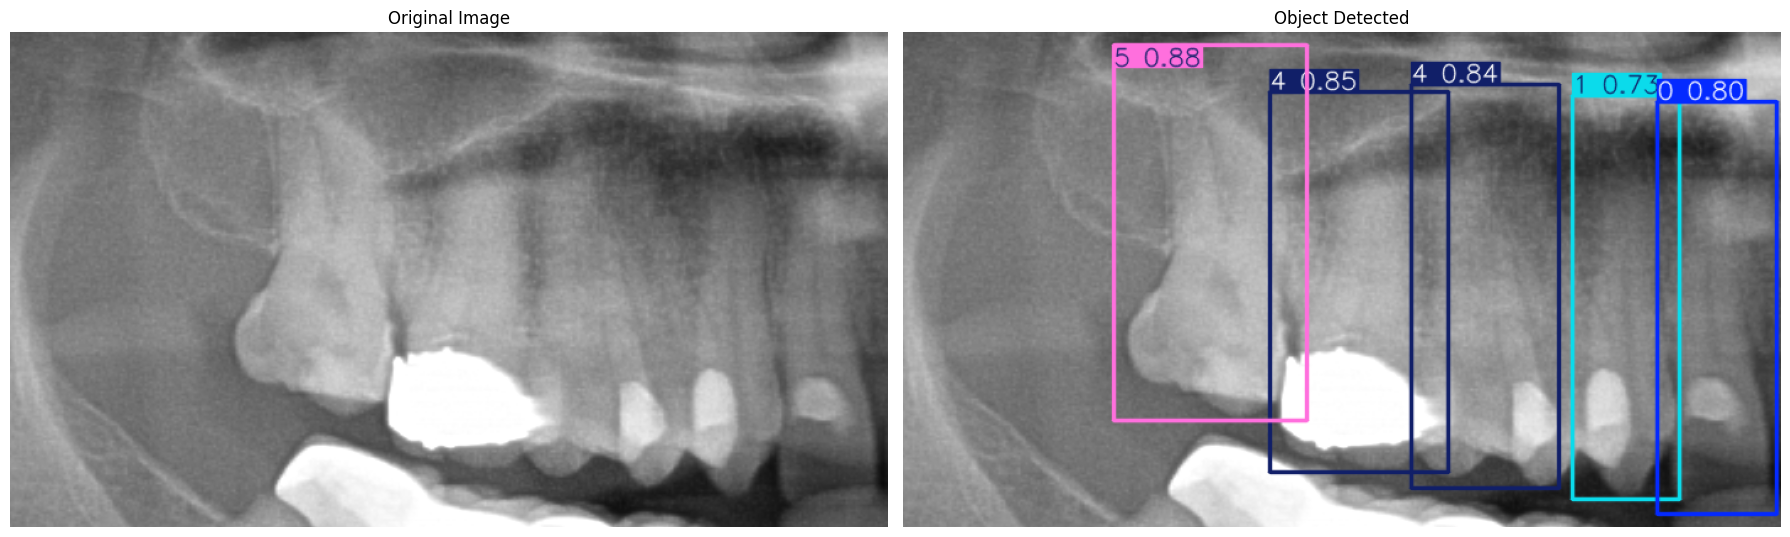

In [ ]:
# run with default settings first, just to confirm the model loads and predicts fine
smart_predict(teeth_model_detection,enum_cont_data_yaml['test'])


image 1/1 c:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Notebooks\..\Data\Processed\Stage 2 Continued (Healthy & Disease Enumeration Detection)\test\images\train_201_UpperRight.png: 736x1280 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 19.6ms
Speed: 5.2ms preprocess, 19.6ms inference, 0.6ms postprocess per image at shape (1, 3, 736, 1280)
Class Name: 6
Coordinates: [245.68031311035156, 102.0030288696289, 438.135986328125, 469.5369873046875]
Confidence: %98.0
Class Name: 0
Coordinates: [882.8965454101562, 169.75711059570312, 1022.5465698242188, 548.5580444335938]
Confidence: %98.0
Class Name: 1
Coordinates: [791.7605590820312, 181.1707763671875, 919.1844482421875, 553.6790161132812]
Confidence: %98.0
Class Name: 2
Coordinates: [696.67626953125, 169.25347900390625, 831.9461669921875, 559.55029296875]
Confidence: %98.0
Class Name: 5
Coordinates: [366.32818603515625, 137.5146484375, 571.2672119140625, 511.2821960449219]
Confidence: %97.0
Class Na

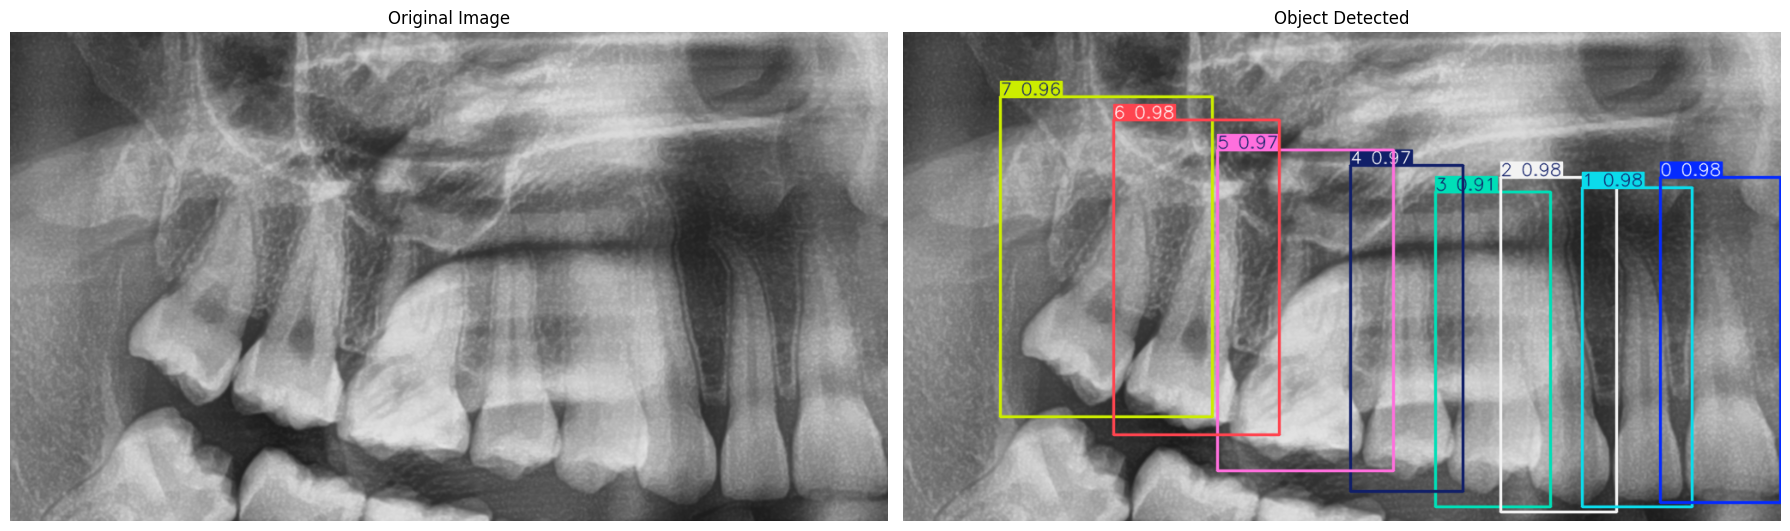

In [8]:
# same predictions, but save the annotated output images this time
smart_predict(teeth_model_detection,enum_cont_data_yaml['test'],save_output=True,save_dir=os.path.join(stage2_cont_config['paths']['runs_s2_cont_output'],'Test Outputs Predictions'))


image 1/1 c:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Notebooks\..\Data\Processed\Stage 2 Continued (Healthy & Disease Enumeration Detection)\test\images\train_465_LowerLeft.png: 800x1280 1 0, 1 1, 1 2, 1 3, 2 4s, 1 6, 1 7, 52.2ms
Speed: 21.0ms preprocess, 52.2ms inference, 0.5ms postprocess per image at shape (1, 3, 800, 1280)
Class Name: 2
Coordinates: [127.125732421875, 163.16329956054688, 244.70828247070312, 528.5216674804688]
Confidence: %97.0
Class Name: 4
Coordinates: [270.1341247558594, 154.39686584472656, 448.17535400390625, 513.245361328125]
Confidence: %97.0
Class Name: 7
Coordinates: [545.378173828125, 44.91596984863281, 827.9421997070312, 311.35491943359375]
Confidence: %97.0
Class Name: 1
Coordinates: [58.17526626586914, 169.03363037109375, 146.98480224609375, 503.78912353515625]
Confidence: %97.0
Class Name: 6
Coordinates: [420.9958801269531, 95.96477508544922, 732.7047729492188, 420.31732177734375]
Confidence: %96.0
Cla

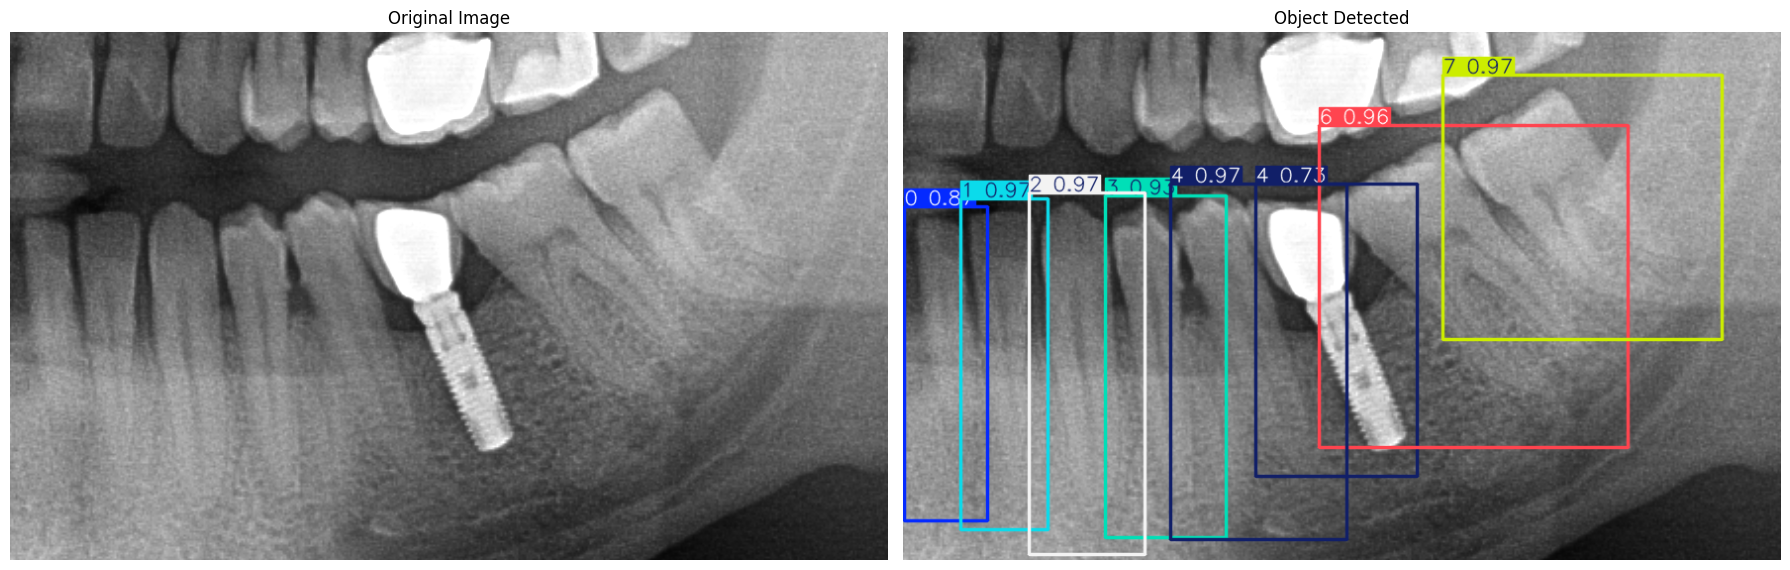

In [10]:
# save the cropped teeth images instead of full annotated frames
smart_predict(teeth_model_detection,enum_cont_data_yaml['test'],save_crop_output_image=True,save_dir=os.path.join(stage2_cont_config['paths']['runs_s2_cont_output'],'Test Outputs Predictions'))


image 1/1 c:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Notebooks\..\Data\Processed\Stage 2 (Enumeration Detection)\test\images\train_145_UpperLeft.png: 640x1280 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 322.5ms
Speed: 18.8ms preprocess, 322.5ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 1280)
Class Name: 0
Coordinates: [0.29012784361839294, 75.349853515625, 96.79439544677734, 367.74737548828125]
Confidence: %97.0
Class Name: 4
Coordinates: [272.8607482910156, 52.273963928222656, 392.92205810546875, 357.89202880859375]
Confidence: %96.0
Class Name: 2
Coordinates: [141.19032287597656, 41.143131256103516, 244.7932891845703, 364.3366394042969]
Confidence: %96.0
Class Name: 6
Coordinates: [479.7934265136719, 48.72349548339844, 627.68310546875, 353.13885498046875]
Confidence: %96.0
Class Name: 1
Coordinates: [79.7866439819336, 69.32169342041016, 156.1195068359375, 348.4198913574219]
Confidence: %96.0
Class Name: 7
Coordinates: 

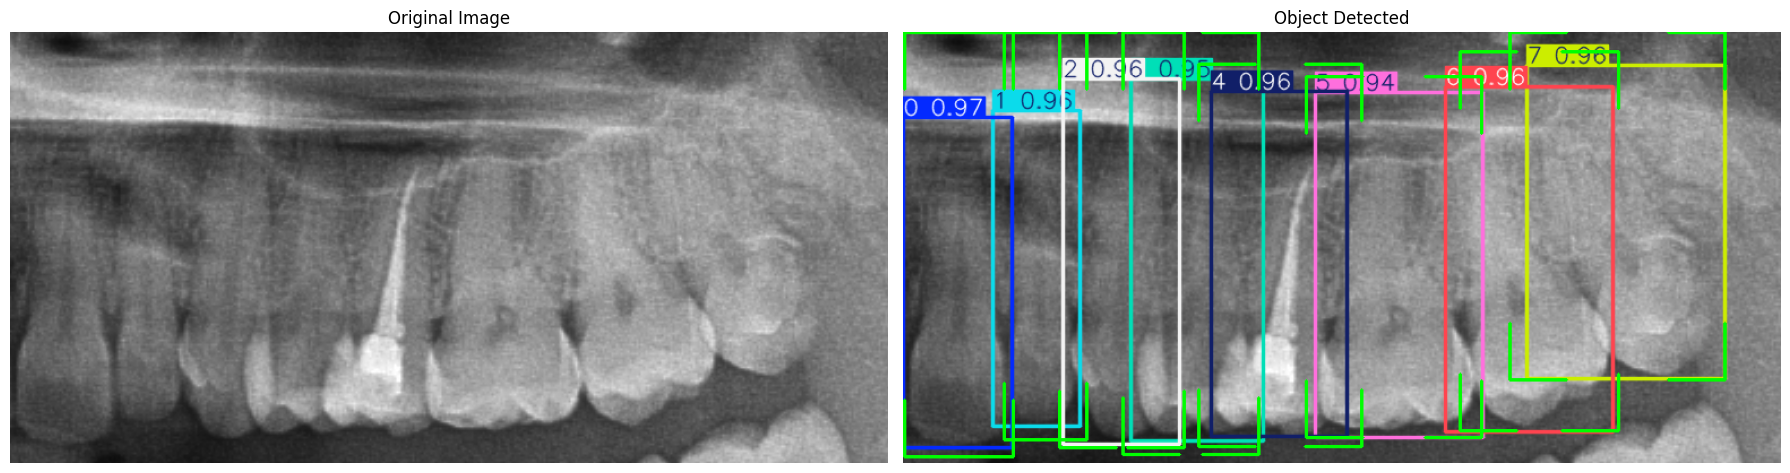

In [ ]:
# overlay the ground-truth boxes next to the predictions for a visual comparison
smart_predict(teeth_model_detection,enum_cont_data_yaml['test'],show_true_boxes=True)


image 1/1 c:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Notebooks\..\Data\Processed\Stage 2 (Enumeration Detection)\test\images\train_355_LowerRight.png: 768x1280 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 117.8ms
Speed: 12.4ms preprocess, 117.8ms inference, 0.5ms postprocess per image at shape (1, 3, 768, 1280)
Class Name: 0
Coordinates: [785.6795043945312, 118.48395538330078, 876.07373046875, 434.0381774902344]
Confidence: %95.0
Class Name: 5
Coordinates: [227.17335510253906, 87.0454330444336, 505.7327575683594, 408.13287353515625]
Confidence: %94.0
Class Name: 1
Coordinates: [712.2362060546875, 117.52665710449219, 821.896240234375, 445.0766906738281]
Confidence: %93.0
Class Name: 4
Coordinates: [493.905029296875, 101.48722839355469, 615.7950439453125, 448.71966552734375]
Confidence: %93.0
Class Name: 3
Coordinates: [575.8704833984375, 110.14189910888672, 669.37158203125, 464.3889465332031]
Confidence: %92.0
Class Name: 2
Coordinates: [647.454

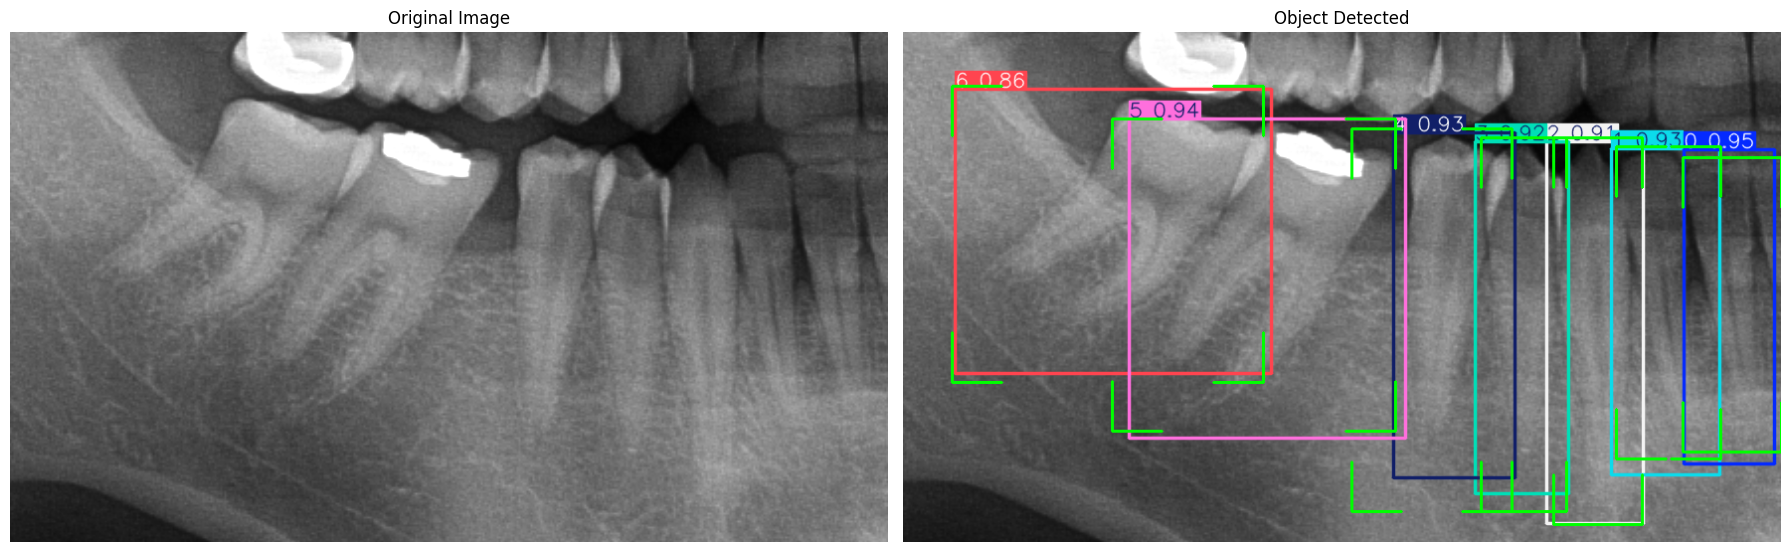

In [ ]:
# overlay the ground-truth boxes next to the predictions for a visual comparison
smart_predict(teeth_model_detection,enum_cont_data_yaml['test'],show_true_boxes=True)